In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import os

# os.listdir('/content/drive/MyDrive/Dataset_ap')


['PetImages']

In [4]:
# import os

# dataset_path = '/content/drive/MyDrive/Dataset_ap/PetImages'

# os.listdir(dataset_path)

['Dog', 'Cat']

In [2]:
# upper 3 cells told me that first we connect to google drive but later we have copied all the dat in google drive

In [3]:
from torchvision import datasets
from torch.utils.data import random_split

dataset_path = '/content/PetImages'

dataset = datasets.ImageFolder(dataset_path)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Total:", len(dataset))
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Total: 25103
Train: 20082
Validation: 2510
Test: 2511


In [13]:
import os
print("Dog images:", len(os.listdir('/content/PetImages/Dog')))
print("Cat images:", len(os.listdir('/content/PetImages/Cat')))

Dog images: 12515
Cat images: 12588


In [25]:
# from torchvision import transforms

# transform = transforms.Compose([
#     transforms.Resize((128, 128)),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=(0.5, 0.5, 0.5),
#         std=(0.5, 0.5, 0.5)
#     )
# ])

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

In [34]:
train_transform = ...
val_test_transform = ...

In [35]:
# train_dataset.dataset.transform = transform
# val_dataset.dataset.transform = transform
# test_dataset.dataset.transform = transform

from torchvision import datasets
from torch.utils.data import Subset

train_full = datasets.ImageFolder(
    '/content/PetImages',
    transform=train_transform
)

val_full = datasets.ImageFolder(
    '/content/PetImages',
    transform=val_test_transform
)

test_full = datasets.ImageFolder(
    '/content/PetImages',
    transform=val_test_transform
)

train_dataset = Subset(train_full, train_dataset.indices)
val_dataset = Subset(val_full, val_dataset.indices)
test_dataset = Subset(test_full, test_dataset.indices)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 20082
Validation: 2510
Test: 2511


In [27]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [28]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 128, 128])
Label batch shape: torch.Size([32])


In [36]:
# build the cnn
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(16 * 16 * 128, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

In [37]:
model = CNN()

In [38]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [39]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

model = model.to(device)

Using device: cuda


In [42]:
epochs = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []
import copy

best_val_accuracy = 0.0
best_epoch = 0
best_model_state = None

for epoch in range(epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Calculate training statistics
        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total


    # ==========================
    # SAVE BEST MODEL
    # ==========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(model.state_dict())

        print("⭐ New best model saved!")

    # =========================
    # SAVE METRICS
    # =========================
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

⭐ New best model saved!
Epoch [1/10] | Train Loss: 0.0263 | Train Acc: 99.15% | Val Loss: 1.0963 | Val Acc: 83.67%
⭐ New best model saved!
Epoch [2/10] | Train Loss: 0.0213 | Train Acc: 99.29% | Val Loss: 1.1781 | Val Acc: 83.71%
Epoch [3/10] | Train Loss: 0.0220 | Train Acc: 99.28% | Val Loss: 0.9619 | Val Acc: 83.39%
Epoch [4/10] | Train Loss: 0.0204 | Train Acc: 99.32% | Val Loss: 1.0354 | Val Acc: 83.31%
Epoch [5/10] | Train Loss: 0.0217 | Train Acc: 99.29% | Val Loss: 1.1478 | Val Acc: 83.11%
Epoch [6/10] | Train Loss: 0.0171 | Train Acc: 99.44% | Val Loss: 1.3220 | Val Acc: 82.11%
Epoch [7/10] | Train Loss: 0.0170 | Train Acc: 99.52% | Val Loss: 1.1781 | Val Acc: 82.03%
Epoch [8/10] | Train Loss: 0.0189 | Train Acc: 99.36% | Val Loss: 1.2895 | Val Acc: 82.55%
Epoch [9/10] | Train Loss: 0.0282 | Train Acc: 99.10% | Val Loss: 1.1570 | Val Acc: 82.75%
Epoch [10/10] | Train Loss: 0.0122 | Train Acc: 99.64% | Val Loss: 1.3653 | Val Acc: 83.07%


In [43]:
print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

Best Epoch: 2
Best Validation Accuracy: 83.70517928286853


In [44]:
model.load_state_dict(best_model_state)

print("Best model loaded!")
print("Using Epoch:", best_epoch)
print("Validation Accuracy:", best_val_accuracy)

Best model loaded!
Using Epoch: 2
Validation Accuracy: 83.70517928286853


In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())


# Calculate metrics
accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(all_labels, all_predictions)

recall = recall_score(all_labels, all_predictions)

cm = confusion_matrix(all_labels, all_predictions)


# Print final results
print("====================================")
print("       FINAL TEST RESULTS")
print("====================================")

print("Best Model Epoch       :", best_epoch)
print("Best Validation Acc    :", f"{best_val_accuracy:.2f}%")

print("\nTest Accuracy          :", f"{accuracy * 100:.2f}%")
print("Test Precision         :", f"{precision * 100:.2f}%")
print("Test Recall            :", f"{recall * 100:.2f}%")

print("\nConfusion Matrix:")
print(cm)

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


       FINAL TEST RESULTS
Best Model Epoch       : 2
Best Validation Acc    : 83.71%

Test Accuracy          : 84.03%
Test Precision         : 81.49%
Test Recall            : 88.60%

Confusion Matrix:
[[ 983  256]
 [ 145 1127]]


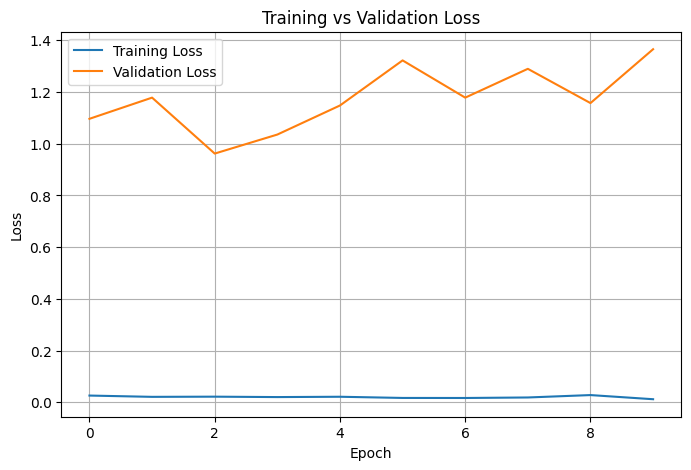

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()

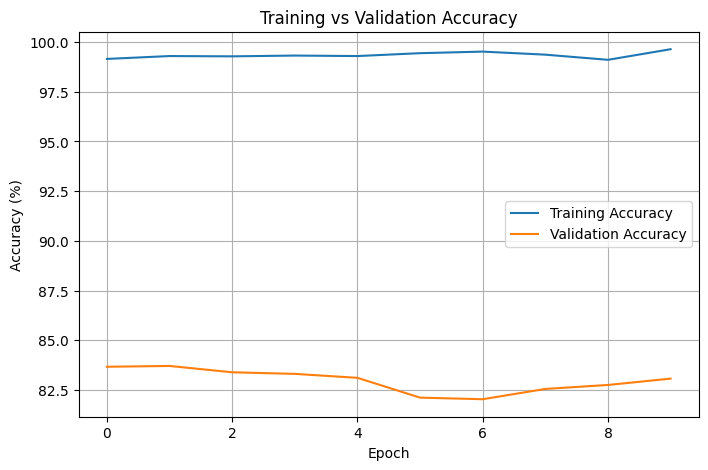

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

In [1]:
import shutil

source = '/content/drive/MyDrive/Dataset_ap/PetImages'
destination = '/content/PetImages'

shutil.copytree(source, destination, dirs_exist_ok=True)

print("Dataset copied to:", destination)

Dataset copied to: /content/PetImages


In [48]:
# #summary

# # 🐱🐶 CNN Binary Image Classification — Cats vs Dogs

# ## 1. Project Objective

# The goal of this project is to build a Convolutional Neural Network (CNN) for binary image classification.

# The model takes an image as input and predicts whether the image contains:

# - Cat → Class 0
# - Dog → Class 1

# The final model is evaluated using:

# - Accuracy
# - Precision
# - Recall
# - Confusion Matrix


# ---

# # 2. Dataset

# The dataset is stored in:

# `/content/PetImages`

# with the following structure:

# PetImages/
# ├── Cat/
# └── Dog/

# The dataset contains approximately 25,103 images:

# - Cat = 12,588
# - Dog = 12,515
# - Total = 25,103

# `ImageFolder` is used because the folder names automatically represent the classes.


# ---

# # 3. Train / Validation / Test Split

# The dataset is divided into three parts:

# - Training = 80%
# - Validation = 10%
# - Testing = 10%

# Actual split:

# - Training = 20,082 images
# - Validation = 2,510 images
# - Testing = 2,511 images

# ### Purpose of each dataset

# ### Training Set
# Used to train the CNN and update its weights.

# ### Validation Set
# Used during development to check how well the model generalizes to unseen images and to select the best model/epoch.

# ### Test Set
# Used only for the final evaluation of the selected best model.

# Important:

# The test set should not be used to decide which epoch/model is best.


# ---

# # 4. Image Preprocessing

# The original images can have different sizes, so all images are resized to:

# 128 × 128 pixels

# The images are RGB, therefore each image has:

# 128 × 128 × 3

# The preprocessing pipeline is:

# Resize
# ↓
# ToTensor
# ↓
# Normalize

# Normalization is performed using:

# Mean = (0.5, 0.5, 0.5)
# Standard deviation = (0.5, 0.5, 0.5)

# For CNN images, we do not use StandardScaler as we would for traditional tabular machine learning.


# ---

# # 5. Data Augmentation

# Data augmentation is applied only to the training data.

# We used:

# - Random Horizontal Flip
# - Random Rotation of 10 degrees

# Purpose:

# Data augmentation creates slightly different versions of training images and helps the CNN generalize better instead of memorizing the training images.

# Training:

# Resize
# ↓
# Random Horizontal Flip
# ↓
# Random Rotation
# ↓
# ToTensor
# ↓
# Normalize

# Validation/Test:

# Resize
# ↓
# ToTensor
# ↓
# Normalize

# Validation and test images are not randomly augmented because they should represent the real data used for evaluation.


# ---

# # 6. DataLoader

# PyTorch DataLoader is used to provide images to the CNN in batches.

# Batch size = 32

# Instead of giving all images to the CNN at once, the model receives:

# 32 images
# ↓
# CNN
# ↓
# Prediction
# ↓
# Loss
# ↓
# Weight update

# Training DataLoader uses:

# shuffle = True

# Validation and Test DataLoaders use:

# shuffle = False


# ---

# # 7. CNN Architecture

# The CNN consists of three convolutional blocks followed by fully connected layers.

# Architecture:

# Input
# 128 × 128 × 3
# ↓
# Conv2D: 3 → 32
# ↓
# ReLU
# ↓
# Max Pooling
# ↓
# Conv2D: 32 → 64
# ↓
# ReLU
# ↓
# Max Pooling
# ↓
# Conv2D: 64 → 128
# ↓
# ReLU
# ↓
# Max Pooling
# ↓
# Flatten
# ↓
# Linear: 32768 → 256
# ↓
# ReLU
# ↓
# Linear: 256 → 2
# ↓
# Cat / Dog


# ### Meaning of 3 → 32

# The first 3 represents the RGB input channels:

# R, G, B

# The 32 represents the number of filters used by the first convolutional layer.

# The CNN then increases the number of feature maps:

# 3 → 32 → 64 → 128

# As the network becomes deeper, it learns increasingly complex features.

# Early layers can learn features such as edges and textures.

# Deeper layers can learn more complex features such as shapes, ears, eyes, faces, and fur patterns.


# ---

# # 8. Max Pooling

# Max pooling is used to reduce the spatial dimensions of the feature maps.

# The dimensions approximately change as:

# 128 × 128
# ↓
# 64 × 64
# ↓
# 32 × 32
# ↓
# 16 × 16

# At the same time, the number of feature maps increases:

# 3 → 32 → 64 → 128

# Therefore, the CNN gradually reduces spatial size while learning more feature channels.


# ---

# # 9. Flattening and Fully Connected Layers

# After the convolutional layers, the feature maps have dimensions:

# 16 × 16 × 128

# These are flattened:

# 16 × 16 × 128 = 32,768

# Therefore the first fully connected layer receives 32,768 inputs:

# Linear: 32768 → 256

# Then:

# ReLU

# Then:

# Linear: 256 → 2

# There are two final outputs because this is a binary classification problem:

# 0 → Cat
# 1 → Dog


# ---

# # 10. Loss Function

# CrossEntropyLoss is used:

# CrossEntropyLoss

# The loss measures how different the model's predictions are from the actual labels.

# During training, the objective is to reduce the loss.

# Lower loss generally means the model's predictions are becoming better.


# ---

# # 11. Optimizer

# The Adam optimizer is used with:

# Learning rate = 0.001

# The basic training process is:

# Forward Pass
# ↓
# Calculate Loss
# ↓
# Backpropagation
# ↓
# Calculate Gradients
# ↓
# Optimizer Updates Weights

# The optimizer changes the CNN weights so that the model can improve its predictions.


# ---

# # 12. Training and Validation

# Each epoch has two main stages.

# ## Training

# `model.train()` is used.

# During training:

# Images
# ↓
# CNN
# ↓
# Predictions
# ↓
# Loss
# ↓
# Backpropagation
# ↓
# Weight Update

# The model learns from the training data.

# ## Validation

# `model.eval()` is used.

# Validation is performed using `torch.no_grad()`.

# During validation:

# Images
# ↓
# CNN
# ↓
# Predictions
# ↓
# Calculate Validation Loss and Accuracy

# The model weights are NOT updated during validation.

# The purpose of validation is to determine how well the current model performs on unseen data.


# ---

# # 13. Overfitting

# The model showed overfitting.

# In the final training run:

# Epoch 1:
# Training Accuracy ≈ 99.15%
# Validation Accuracy ≈ 83.67%

# Epoch 2:
# Training Accuracy ≈ 99.29%
# Validation Accuracy ≈ 83.71%

# Epoch 10:
# Training Accuracy ≈ 99.64%
# Validation Accuracy ≈ 83.07%

# After the early epochs, training accuracy continued to increase while validation accuracy generally decreased or remained lower.

# This means the model became very good at fitting the training images but did not improve correspondingly on unseen validation images.

# This is called overfitting.


# ---

# # 14. Training vs Validation Accuracy Graph

# The accuracy graph compares:

# Training Accuracy
# vs
# Validation Accuracy

# The graph shows that training accuracy remains extremely high, while validation accuracy is much lower and does not improve after the early epochs.

# This indicates a generalization gap and supports the conclusion that the model is overfitting.


# ---

# # 15. Training vs Validation Loss Graph

# The loss graph compares:

# Training Loss
# vs
# Validation Loss

# Training loss became very low.

# Validation loss remained considerably higher and generally increased after the early epochs.

# This is another indication of overfitting.

# For example, the final training run had approximately:

# Epoch 1 Validation Loss = 1.0963
# Epoch 2 Validation Loss = 1.1781
# Epoch 3 Validation Loss = 0.9619
# ...
# Epoch 10 Validation Loss = 1.3653

# The validation loss fluctuates, but the overall behavior after the early epochs indicates poor generalization compared with the training performance.


# ---

# # 16. Best Model Selection

# Initially, the training loop did not save the best model weights.

# We then modified the training loop to automatically save the model whenever validation accuracy improved.

# The important logic is:

# if validation accuracy > best validation accuracy:
#     save the current model weights

# This allows us to keep the actual neural-network weights from the best-performing epoch.

# In the final training run:

# Best Epoch = 2

# Best Validation Accuracy = 83.71%

# Therefore, Epoch 2 was selected as the best model.

# The saved weights were loaded using:

# model.load_state_dict(best_model_state)

# This ensures that the final test evaluation uses the best validation model rather than simply using the last epoch.


# ---

# # 17. Why Epoch 2 Instead of Epoch 10?

# Epoch 2 achieved:

# Validation Accuracy = 83.71%

# Epoch 10 achieved:

# Validation Accuracy = 83.07%

# Although training accuracy continued increasing until Epoch 10, validation performance did not improve.

# Therefore, Epoch 2 is the better model because it generalized better to unseen validation data.

# The important principle is:

# Choose the model with the best validation performance, not automatically the final epoch.


# ---

# # 18. Final Test Evaluation

# After selecting the best model, the saved Epoch-2 weights were loaded.

# The model was then evaluated on the completely separate test dataset.

# Final test results:

# Test Accuracy = 83.27%

# Test Precision = 81.65%

# Test Recall = 86.40%


# ---

# # 19. Accuracy

# Test Accuracy = 83.27%

# Accuracy tells us the percentage of all test images that were classified correctly.

# Approximately 83 out of every 100 unseen test images were classified correctly.


# ---

# # 20. Precision

# Test Precision = 81.65%

# The positive class is Dog (class 1).

# Precision answers:

# "When the model predicts Dog, how often is that prediction actually a Dog?"

# The model's precision for Dog is approximately 81.65%.


# ---

# # 21. Recall

# Test Recall = 86.40%

# Recall answers:

# "Of all the actual Dogs in the test dataset, how many did the model successfully identify?"

# The model successfully identified approximately 86.40% of the actual Dogs.


# ---

# # 22. Confusion Matrix

# Final confusion matrix:

# [[992, 247],
#  [173, 1099]]

# Class mapping:

# Cat = 0
# Dog = 1

# Therefore:

#                  Predicted
#                  Cat     Dog

# Actual Cat       992     247
# Actual Dog       173    1099


# Interpretation:

# 992 Cats were correctly classified as Cats.

# 247 Cats were incorrectly classified as Dogs.

# 173 Dogs were incorrectly classified as Cats.

# 1099 Dogs were correctly classified as Dogs.


# Correct predictions:

# 992 + 1099 = 2091

# Total test images:

# 2511

# This produces approximately 83.27% test accuracy.


# ---

# # 23. Final Results

# Best Model:

# Epoch = 2

# Best Validation Accuracy = 83.71%


# Final Test Performance:

# Accuracy = 83.27%

# Precision = 81.65%

# Recall = 86.40%


# The CNN successfully performs binary classification of cats and dogs.

# The model achieves satisfactory performance within the required 80–95% accuracy range.

# However, the training and validation curves indicate overfitting because training performance is extremely high while validation performance remains significantly lower.


# ---

# # 24. Complete Pipeline

# Dataset
# ↓
# Train / Validation / Test Split
# ↓
# Image Preprocessing
# ↓
# Data Augmentation
# ↓
# DataLoader
# ↓
# CNN Architecture
# ↓
# Training
# ↓
# Validation after every epoch
# ↓
# Monitor Validation Accuracy
# ↓
# Save Best Model
# ↓
# Best Model = Epoch 2
# ↓
# Load Best Model
# ↓
# Evaluate on Test Dataset
# ↓
# Accuracy
# Precision
# Recall
# Confusion Matrix
# ↓
# Analyze Training/Validation Curves
# ↓
# Final Conclusion


# ---

# # 25. Most Important Concepts to Remember

# 1. Training data is used to learn the model weights.

# 2. Validation data is used to monitor performance and select the best model.

# 3. Test data is used for the final unbiased evaluation.

# 4. Data augmentation is applied only to training data.

# 5. CNN convolutional layers extract image features.

# 6. ReLU introduces non-linearity.

# 7. Max pooling reduces spatial dimensions.

# 8. CrossEntropyLoss measures classification error.

# 9. Adam updates the model weights.

# 10. Overfitting occurs when training performance keeps improving while validation performance stops improving or becomes worse.

# 11. The best model is selected using validation performance.

# 12. In this project, the best model was Epoch 2 with 83.71% validation accuracy.

# 13. The final test performance was 83.27% accuracy, 81.65% precision, and 86.40% recall.